Import Libraries

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [243]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

Loading Dataset

In [246]:
df = pd.read_csv("C:/ElevateLabs/Project/healthcare_noshows.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


In [248]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106987 entries, 0 to 106986
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       106987 non-null  float64
 1   AppointmentID   106987 non-null  int64  
 2   Gender          106987 non-null  object 
 3   ScheduledDay    106987 non-null  object 
 4   AppointmentDay  106987 non-null  object 
 5   Age             106987 non-null  int64  
 6   Neighbourhood   106987 non-null  object 
 7   Scholarship     106987 non-null  bool   
 8   Hipertension    106987 non-null  bool   
 9   Diabetes        106987 non-null  bool   
 10  Alcoholism      106987 non-null  bool   
 11  Handcap         106987 non-null  bool   
 12  SMS_received    106987 non-null  bool   
 13  Showed_up       106987 non-null  bool   
 14  Date.diff       106987 non-null  int64  
dtypes: bool(7), float64(1), int64(3), object(4)
memory usage: 7.2+ MB


,PatientId,AppointmentID,Age,Date.diff
count,1.069870e+05,1.069870e+05,106987.000000,106987.000000
mean,1.472814e+14,5.675434e+06,38.316085,10.166721
std,2.558267e+14,7.133274e+04,22.466214,15.263508
min,3.921784e+04,5.030230e+06,1.000000,-6.000000
25%,4.173523e+12,5.640490e+06,19.000000,0.000000
50%,3.172463e+13,5.680744e+06,38.000000,4.000000
75%,9.433600e+13,5.725634e+06,56.000000,14.000000
max,9.999816e+14,5.790484e+06,115.000000,179.000000


Data cleaning

In [251]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
Showed_up         0
Date.diff         0
dtype: int64

In [253]:
df = df.dropna()

In [255]:
df.columns = df.columns.str.lower().str.strip().str.replace('-', '_')
df.columns

Index(['patientid', 'appointmentid', 'gender', 'scheduledday',
       'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension',
       'diabetes', 'alcoholism', 'handcap', 'sms_received', 'showed_up',
       'date.diff'],
      dtype='object')

In [257]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [259]:
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

In [261]:
df['waiting_days'] = (df['appointmentday'] - df['scheduledday']).dt.days

In [263]:
print(df.columns)

Index(['patientid', 'appointmentid', 'gender', 'scheduledday',
       'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension',
       'diabetes', 'alcoholism', 'handcap', 'sms_received', 'showed_up',
       'date.diff', 'waiting_days'],
      dtype='object')


In [269]:
df['no_show'] = df['showed_up'].apply(lambda x: 0 if x == True else 1)

In [271]:
df['no_show'].value_counts()

no_show
0    85307
1    21680
Name: count, dtype: int64

In [273]:
df = df[(df['age'] >= 0) & (df['age'] <= 100)]

In [287]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 106980 entries, 0 to 106986
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   gender               106980 non-null  object  
 1   age                  106980 non-null  int64   
 2   neighbourhood        106980 non-null  object  
 3   scholarship          106980 non-null  bool    
 4   hipertension         106980 non-null  bool    
 5   diabetes             106980 non-null  bool    
 6   alcoholism           106980 non-null  bool    
 7   handcap              106980 non-null  bool    
 8   sms_received         106980 non-null  bool    
 9   waiting_days         106980 non-null  int64   
 10  no_show              106980 non-null  int64   
 11  appointment_weekday  106980 non-null  object  
 12  age_group            106980 non-null  category
dtypes: bool(6), category(1), int64(3), object(3)
memory usage: 6.4+ MB


,gender,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,waiting_days,no_show,appointment_weekday,age_group
0,F,62,JARDIM DA PENHA,False,True,False,False,False,False,0,0,Friday,Senior
1,M,56,JARDIM DA PENHA,False,False,False,False,False,False,0,0,Friday,Adult
2,F,62,MATA DA PRAIA,False,False,False,False,False,False,0,0,Friday,Senior
3,F,8,PONTAL DE CAMBURI,False,False,False,False,False,False,0,0,Friday,Child
4,F,56,JARDIM DA PENHA,False,True,True,False,False,False,0,0,Friday,Adult


In [285]:
print(df.columns)

Index(['gender', 'age', 'neighbourhood', 'scholarship', 'hipertension',
       'diabetes', 'alcoholism', 'handcap', 'sms_received', 'waiting_days',
       'no_show', 'appointment_weekday', 'age_group'],
      dtype='object')


In [289]:
df.rename(columns={'hipertension': 'hypertension'}, inplace=True)

In [291]:
df['gender'] = df['gender'].map({'F':0, 'M':1})

In [293]:
bool_cols = ['scholarship','hypertension','diabetes','alcoholism','handcap','sms_received']

for col in bool_cols:
    df[col] = df[col].astype(int)

In [295]:
df.drop(columns=['neighbourhood'], inplace=True)

In [297]:
df['appointment_weekday'] = df['appointment_weekday'].astype('category').cat.codes

In [299]:
df['age_group'] = df['age_group'].astype('category').cat.codes

In [301]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 106980 entries, 0 to 106986
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   gender               106980 non-null  int64
 1   age                  106980 non-null  int64
 2   scholarship          106980 non-null  int32
 3   hypertension         106980 non-null  int32
 4   diabetes             106980 non-null  int32
 5   alcoholism           106980 non-null  int32
 6   handcap              106980 non-null  int32
 7   sms_received         106980 non-null  int32
 8   waiting_days         106980 non-null  int64
 9   no_show              106980 non-null  int64
 10  appointment_weekday  106980 non-null  int8 
 11  age_group            106980 non-null  int8 
dtypes: int32(6), int64(4), int8(2)
memory usage: 6.7 MB


,gender,age,scholarship,hypertension,diabetes,alcoholism,handcap,sms_received,waiting_days,no_show,appointment_weekday,age_group
0,0,62,0,1,0,0,0,0,0,0,0,4
1,1,56,0,0,0,0,0,0,0,0,0,3
2,0,62,0,0,0,0,0,0,0,0,0,4
3,0,8,0,0,0,0,0,0,0,0,0,0
4,0,56,0,1,1,0,0,0,0,0,0,3


In [303]:
df.to_csv("cleaned_healthcare_noshows.csv", index=False)
print("Cleaned dataset saved successfully ✅")

Cleaned dataset saved successfully ✅


Exploratory Data Analysis (EDA)

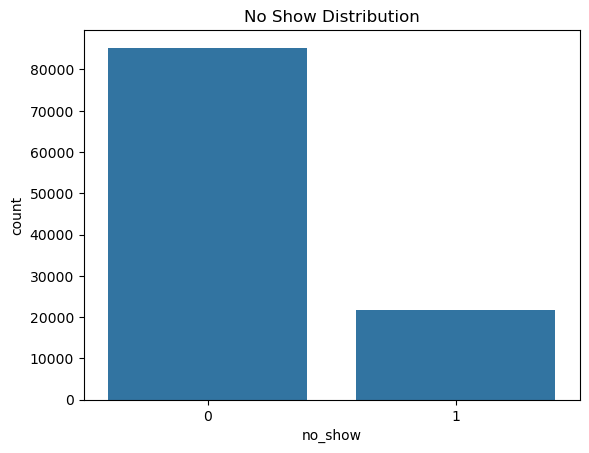

In [306]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='no_show', data=df)
plt.title("No Show Distribution")
plt.show()

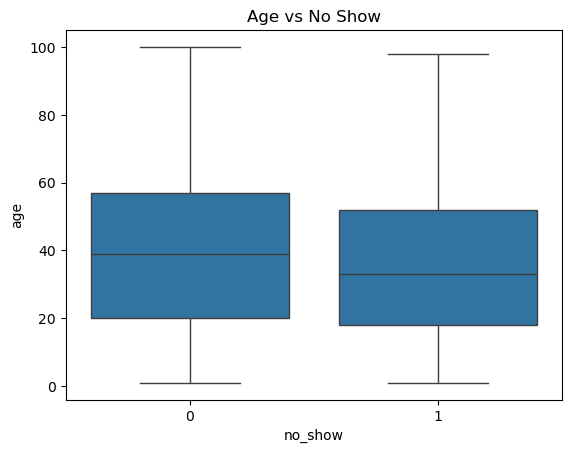

In [308]:
sns.boxplot(x='no_show', y='age', data=df)
plt.title("Age vs No Show")
plt.show()

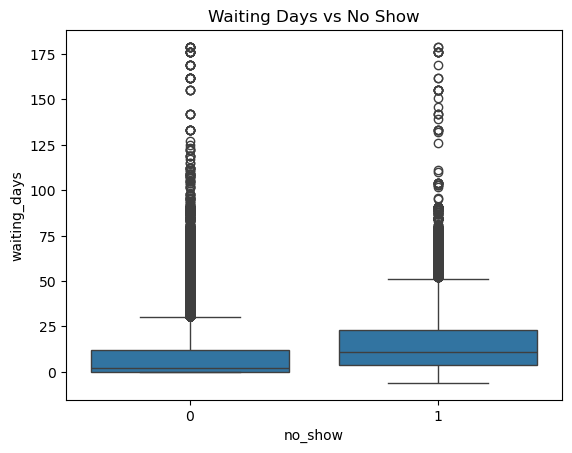

In [310]:
sns.boxplot(x='no_show', y='waiting_days', data=df)
plt.title("Waiting Days vs No Show")
plt.show()

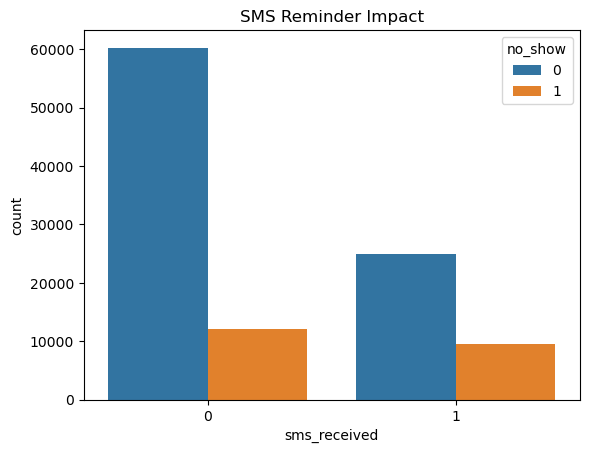

In [312]:
sns.countplot(x='sms_received', hue='no_show', data=df)
plt.title("SMS Reminder Impact")
plt.show()

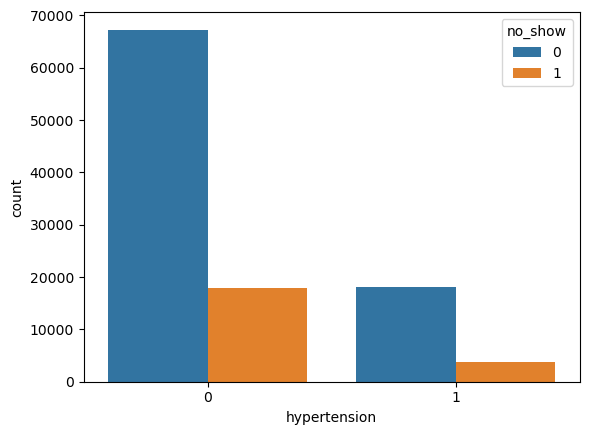

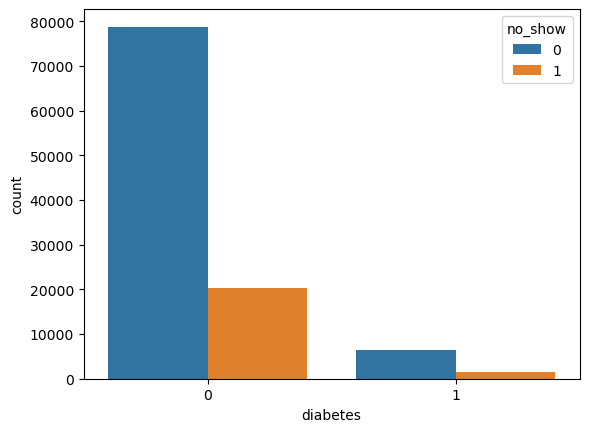

In [314]:
sns.countplot(x='hypertension', hue='no_show', data=df)
plt.show()

sns.countplot(x='diabetes', hue='no_show', data=df)
plt.show()

Machine Learning Model

In [325]:
X = df.drop(columns=['no_show'])
y = df['no_show']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
DecisionTreeClassifier(class_weight='balanced')
y_pred = model.predict(X_test)

In [327]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6887268648345485
              precision    recall  f1-score   support

           0       0.84      0.76      0.80     17127
           1       0.30      0.41      0.35      4269

    accuracy                           0.69     21396
   macro avg       0.57      0.59      0.57     21396
weighted avg       0.73      0.69      0.71     21396

[[12965  4162]
 [ 2498  1771]]


In [329]:
from sklearn.ensemble import RandomForestClassifier

In [331]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [332]:
rf_pred = rf_model.predict(X_test)

In [333]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.7266778837165825
              precision    recall  f1-score   support

           0       0.83      0.83      0.83     17127
           1       0.32      0.33      0.32      4269

    accuracy                           0.73     21396
   macro avg       0.58      0.58      0.58     21396
weighted avg       0.73      0.73      0.73     21396

[[14154  2973]
 [ 2875  1394]]


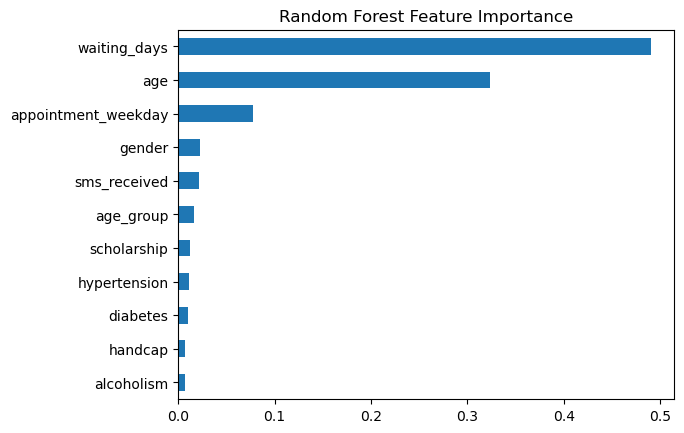

In [337]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.show()

In [341]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Ritu\anaconda3\envs\intel_env\python.exe -m pip install --upgrade pip


In [343]:
from imblearn.over_sampling import SMOTE

In [345]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: no_show
0    68176
1    17408
Name: count, dtype: int64
After SMOTE: no_show
0    68176
1    68176
Name: count, dtype: int64


In [347]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

In [ ]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

rf_tuned.fit(X_train_smote, y_train_smote)

rf_tuned_pred = rf_tuned.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_tuned_pred))
print(classification_report(y_test, rf_tuned_pred))